# М1. Полёт камня

Моделирование броска камня под углом к горизонту. Согласно заданию, рассчитывается траектория движения и исследуется влияние сопротивления воздуха. Мы рассмотрим 3 случая:
1. Идеальный полет (без сопротивления)
2. Вязкое трение (сила сопротивления пропорциональна скорости)
3. Лобовое сопротивление (сила сопротивления пропорциональна квадрату скорости)

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from scipy.integrate import solve_ivp

Vector = npt.NDArray[np.float64]

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['grid.alpha'] = 0.5

## 1. Параметры броска и константы
Задаем ускорение свободного падения, начальную скорость, угол, массу камня и коэффициенты сопротивления среды.

In [41]:
G_ACCEL: float = 9.81

V0: float = 50.0
ALPHA_DEG: float = 45.0
ALPHA_RAD: float = np.radians(ALPHA_DEG)

V0_X: float = V0 * np.cos(ALPHA_RAD)
V0_Y: float = V0 * np.sin(ALPHA_RAD)

MASS: float = 1.0
K_LINEAR: float = 0.1
K_QUAD: float = 0.005

## 2. Дифференциальные уравнения движения
Решаем систему уравнений движения для каждого случая с помощью численного интегрирования. Условием остановки расчета является падение камня на землю ($y \le 0$).

In [42]:
def hit_ground(t: float, Y: Vector) -> float:
    x, y, vx, vy = Y
    return y

hit_ground.terminal = True
hit_ground.direction = -1

t_span: list[float] = [0, 100]
Y0: list[float] = [0, 0, V0_X, V0_Y]

def no_drag_system(t: float, Y: Vector) -> list[float]:
    x, y, vx, vy = Y
    return [vx, vy, 0, -G_ACCEL]

sol_no_drag = solve_ivp(
    no_drag_system, t_span, Y0,
    events=hit_ground, max_step=0.01
)

def linear_drag_system(t: float, Y: Vector) -> list[float]:
    x, y, vx, vy = Y
    ax: float = -(K_LINEAR / MASS) * vx
    ay: float = -G_ACCEL - (K_LINEAR / MASS) * vy
    return [vx, vy, ax, ay]

sol_linear = solve_ivp(
    linear_drag_system, t_span, Y0,
    events=hit_ground, max_step=0.01
)

def quad_drag_system(t: float, Y: Vector) -> list[float]:
    x, y, vx, vy = Y
    v_mag: float = np.sqrt(vx**2 + vy**2)
    ax: float = -(K_QUAD / MASS) * v_mag * vx
    ay: float = -G_ACCEL - (K_QUAD / MASS) * v_mag * vy
    return [vx, vy, ax, ay]

sol_quad = solve_ivp(
    quad_drag_system, t_span, Y0,
    events=hit_ground, max_step=0.01
)

## 3. Расчет кинетической, потенциальной и полной механической энергии
Для расчета кинетической энергии потребуются обе компоненты скорости.

Для расчета потенциальной энергии потребуется текущую высота.

Полная механическая энергия определяется как сумма кинетической и потенциальной энергий.

`solve_ivp` для каждой модели движения уже возвращает высоту и компоненты скорости в каждый момент времени. Поэтому расчет энергии будет одинаковым для всех сопротивлений.

In [43]:
def calculate_energy(sol) -> tuple[Vector, Vector, Vector]:
    y: Vector = sol.y[1]
    vx: Vector = sol.y[2]
    vy: Vector = sol.y[3]

    E_k: Vector = 0.5 * MASS * (vx**2 + vy**2)
    E_p: Vector = MASS * G_ACCEL * y
    E_total: Vector = E_k + E_p

    return E_k, E_p, E_total

E_k_no_drag, E_p_no_drag, E_total_no_drag = calculate_energy(sol_no_drag)

E_k_linear, E_p_linear, E_total_linear = calculate_energy(sol_linear)

E_k_quad, E_p_quad, E_total_quad = calculate_energy(sol_quad)

## 4. Сравнение с теоретическим расчетом и визуализация
Для движения без трения мы можем рассчитать точную траекторию аналитически и сравнить ее с результатом численного решения.

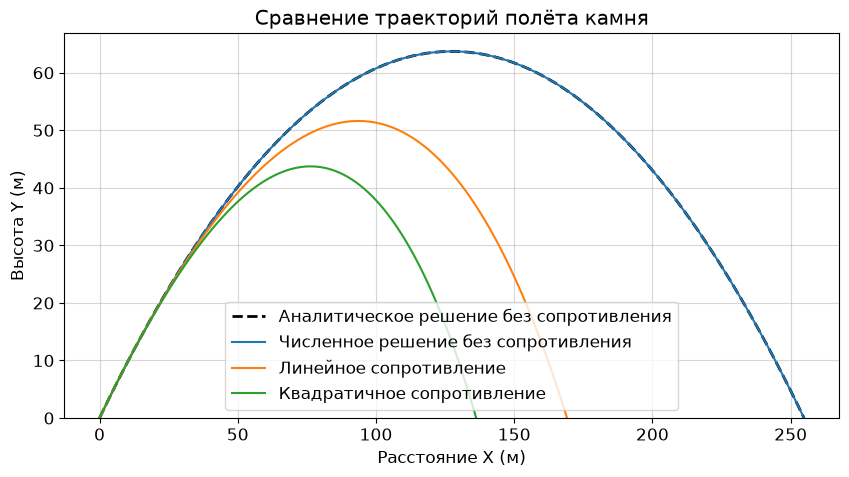

In [44]:
t_theory: Vector = np.linspace(0, 2 * V0_Y / G_ACCEL, 100)
x_theory: Vector = V0_X * t_theory
y_theory: Vector = V0_Y * t_theory - 0.5 * G_ACCEL * t_theory**2

plt.plot(x_theory, y_theory, 'k--', linewidth=2, label='Аналитическое решение без сопротивления')
plt.plot(sol_no_drag.y[0], sol_no_drag.y[1], label='Численное решение без сопротивления')
plt.plot(sol_linear.y[0], sol_linear.y[1], label='Линейное сопротивление')
plt.plot(sol_quad.y[0], sol_quad.y[1], label='Квадратичное сопротивление')

plt.title('Сравнение траекторий полёта камня')
plt.xlabel('Расстояние X (м)')
plt.ylabel('Высота Y (м)')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)
plt.show()

## 5. Визуализация изменения кинетической, потенциальной и полной механической энергии

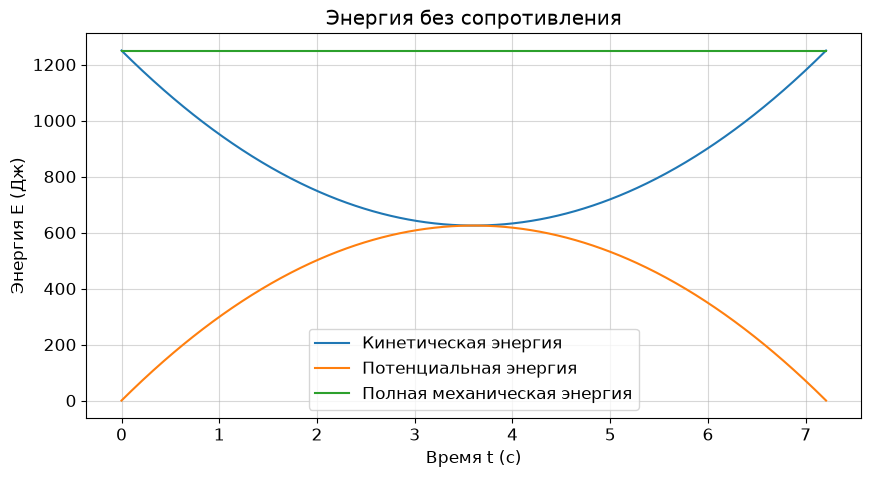

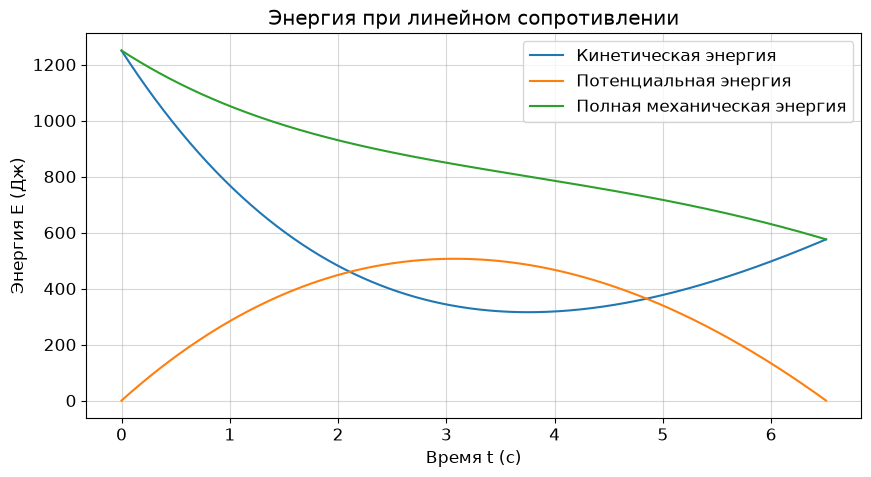

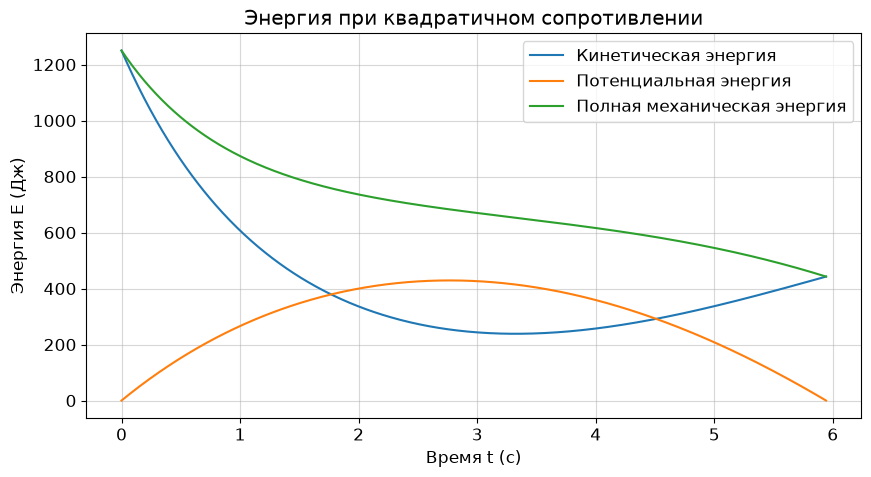

In [45]:
# Без сопротивления

plt.plot(sol_no_drag.t, E_k_no_drag, label='Кинетическая энергия')
plt.plot(sol_no_drag.t, E_p_no_drag, label='Потенциальная энергия')
plt.plot(sol_no_drag.t, E_total_no_drag, label='Полная механическая энергия')

plt.title('Энергия без сопротивления')
plt.xlabel('Время t (с)')
plt.ylabel('Энергия E (Дж)')
plt.legend()
plt.grid(True)
plt.show()


# Линейное сопротивление

plt.plot(sol_linear.t, E_k_linear, label='Кинетическая энергия')
plt.plot(sol_linear.t, E_p_linear, label='Потенциальная энергия')
plt.plot(sol_linear.t, E_total_linear, label='Полная механическая энергия')

plt.title('Энергия при линейном сопротивлении')
plt.xlabel('Время t (с)')
plt.ylabel('Энергия E (Дж)')
plt.legend()
plt.grid(True)
plt.show()


# Квадратичное сопротивление

plt.plot(sol_quad.t, E_k_quad, label='Кинетическая энергия')
plt.plot(sol_quad.t, E_p_quad, label='Потенциальная энергия')
plt.plot(sol_quad.t, E_total_quad, label='Полная механическая энергия')

plt.title('Энергия при квадратичном сопротивлении')
plt.xlabel('Время t (с)')
plt.ylabel('Энергия E (Дж)')
plt.legend()
plt.grid(True)
plt.show()